# Import Library

In [119]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score, matthews_corrcoef
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline import Pipeline

# Dataset

## Train Dataset

### Tabel Data Train

In [120]:
df_train = pd.read_csv('home-credit-default-risk/application_train.csv')
df_train.head()

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0


### Informasi Data Secara Keseluruhan

In [121]:
df_train.info('all')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 307511 entries, 0 to 307510
Data columns (total 122 columns):
 #    Column                        Dtype  
---   ------                        -----  
 0    SK_ID_CURR                    int64  
 1    TARGET                        int64  
 2    NAME_CONTRACT_TYPE            object 
 3    CODE_GENDER                   object 
 4    FLAG_OWN_CAR                  object 
 5    FLAG_OWN_REALTY               object 
 6    CNT_CHILDREN                  int64  
 7    AMT_INCOME_TOTAL              float64
 8    AMT_CREDIT                    float64
 9    AMT_ANNUITY                   float64
 10   AMT_GOODS_PRICE               float64
 11   NAME_TYPE_SUITE               object 
 12   NAME_INCOME_TYPE              object 
 13   NAME_EDUCATION_TYPE           object 
 14   NAME_FAMILY_STATUS            object 
 15   NAME_HOUSING_TYPE             object 
 16   REGION_POPULATION_RELATIVE    float64
 17   DAYS_BIRTH                    int64  
 18   DA

### Cek Missing Values

In [122]:
df_train.isna().sum()

SK_ID_CURR                        0
TARGET                            0
NAME_CONTRACT_TYPE                0
CODE_GENDER                       0
FLAG_OWN_CAR                      0
                              ...  
AMT_REQ_CREDIT_BUREAU_DAY     41519
AMT_REQ_CREDIT_BUREAU_WEEK    41519
AMT_REQ_CREDIT_BUREAU_MON     41519
AMT_REQ_CREDIT_BUREAU_QRT     41519
AMT_REQ_CREDIT_BUREAU_YEAR    41519
Length: 122, dtype: int64

### Cek Duplikat Data

In [123]:
df_train.duplicated().sum()

0

### Deskripsi Data Secara Keseluruhan

In [124]:
df_train.describe(include='all')

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
count,307511.000000,307511.000000,307511,307511,307511,307511,307511.000000,3.075110e+05,3.075110e+05,307499.000000,...,307511.000000,307511.000000,307511.000000,307511.000000,265992.000000,265992.000000,265992.000000,265992.000000,265992.000000,265992.000000
unique,NaN,NaN,2,3,2,2,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,NaN,Cash loans,F,N,Y,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,NaN,278232,202448,202924,213312,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,278180.518577,0.080729,NaN,NaN,NaN,NaN,0.417052,1.687979e+05,5.990260e+05,27108.573909,...,0.008130,0.000595,0.000507,0.000335,0.006402,0.007000,0.034362,0.267395,0.265474,1.899974
std,102790.175348,0.272419,NaN,NaN,NaN,NaN,0.722121,2.371231e+05,4.024908e+05,14493.737315,...,0.089798,0.024387,0.022518,0.018299,0.083849,0.110757,0.204685,0.916002,0.794056,1.869295
min,100002.000000,0.000000,NaN,NaN,NaN,NaN,0.000000,2.565000e+04,4.500000e+04,1615.500000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,189145.500000,0.000000,NaN,NaN,NaN,NaN,0.000000,1.125000e+05,2.700000e+05,16524.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,278202.000000,0.000000,NaN,NaN,NaN,NaN,0.000000,1.471500e+05,5.135310e+05,24903.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
75%,367142.500000,0.000000,NaN,NaN,NaN,NaN,1.000000,2.025000e+05,8.086500e+05,34596.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.000000


## Test Dataset

### Tabel Data Test

In [125]:
df_test = pd.read_csv('home-credit-default-risk/application_test.csv')
df_test.head()

,SK_ID_CURR,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100001,Cash loans,F,N,Y,0,135000.0,568800.0,20560.5,450000.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
1,100005,Cash loans,M,N,Y,0,99000.0,222768.0,17370.0,180000.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,3.0
2,100013,Cash loans,M,Y,Y,0,202500.0,663264.0,69777.0,630000.0,...,0,0,0,0,0.0,0.0,0.0,0.0,1.0,4.0
3,100028,Cash loans,F,N,Y,2,315000.0,1575000.0,49018.5,1575000.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,3.0
4,100038,Cash loans,M,Y,N,1,180000.0,625500.0,32067.0,625500.0,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN


### Informasi Data Secara Keseluruhan

In [126]:
df_test.info('all')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48744 entries, 0 to 48743
Data columns (total 121 columns):
 #    Column                        Dtype  
---   ------                        -----  
 0    SK_ID_CURR                    int64  
 1    NAME_CONTRACT_TYPE            object 
 2    CODE_GENDER                   object 
 3    FLAG_OWN_CAR                  object 
 4    FLAG_OWN_REALTY               object 
 5    CNT_CHILDREN                  int64  
 6    AMT_INCOME_TOTAL              float64
 7    AMT_CREDIT                    float64
 8    AMT_ANNUITY                   float64
 9    AMT_GOODS_PRICE               float64
 10   NAME_TYPE_SUITE               object 
 11   NAME_INCOME_TYPE              object 
 12   NAME_EDUCATION_TYPE           object 
 13   NAME_FAMILY_STATUS            object 
 14   NAME_HOUSING_TYPE             object 
 15   REGION_POPULATION_RELATIVE    float64
 16   DAYS_BIRTH                    int64  
 17   DAYS_EMPLOYED                 int64  
 18   DAYS

### Cek Missing Values

In [127]:
df_test.isna().sum()

SK_ID_CURR                       0
NAME_CONTRACT_TYPE               0
CODE_GENDER                      0
FLAG_OWN_CAR                     0
FLAG_OWN_REALTY                  0
                              ... 
AMT_REQ_CREDIT_BUREAU_DAY     6049
AMT_REQ_CREDIT_BUREAU_WEEK    6049
AMT_REQ_CREDIT_BUREAU_MON     6049
AMT_REQ_CREDIT_BUREAU_QRT     6049
AMT_REQ_CREDIT_BUREAU_YEAR    6049
Length: 121, dtype: int64

### Cek Duplikat Data

In [128]:
df_test.duplicated().sum()

0

### Deskripsi Data Secara Keseluruhan

In [129]:
df_test.describe(include='all')

,SK_ID_CURR,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
count,48744.000000,48744,48744,48744,48744,48744.000000,4.874400e+04,4.874400e+04,48720.000000,4.874400e+04,...,48744.000000,48744.0,48744.0,48744.0,42695.000000,42695.000000,42695.000000,42695.000000,42695.000000,42695.000000
unique,NaN,2,2,2,2,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,Cash loans,F,N,Y,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,48305,32678,32311,33658,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,277796.676350,NaN,NaN,NaN,NaN,0.397054,1.784318e+05,5.167404e+05,29426.240209,4.626188e+05,...,0.001559,0.0,0.0,0.0,0.002108,0.001803,0.002787,0.009299,0.546902,1.983769
std,103169.547296,NaN,NaN,NaN,NaN,0.709047,1.015226e+05,3.653970e+05,16016.368315,3.367102e+05,...,0.039456,0.0,0.0,0.0,0.046373,0.046132,0.054037,0.110924,0.693305,1.838873
min,100001.000000,NaN,NaN,NaN,NaN,0.000000,2.694150e+04,4.500000e+04,2295.000000,4.500000e+04,...,0.000000,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,188557.750000,NaN,NaN,NaN,NaN,0.000000,1.125000e+05,2.606400e+05,17973.000000,2.250000e+05,...,0.000000,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,277549.000000,NaN,NaN,NaN,NaN,0.000000,1.575000e+05,4.500000e+05,26199.000000,3.960000e+05,...,0.000000,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000
75%,367555.500000,NaN,NaN,NaN,NaN,1.000000,2.250000e+05,6.750000e+05,37390.500000,6.300000e+05,...,0.000000,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.000000,1.000000,3.000000


# Data Visualization

## Heatmap Korelasi Fitur

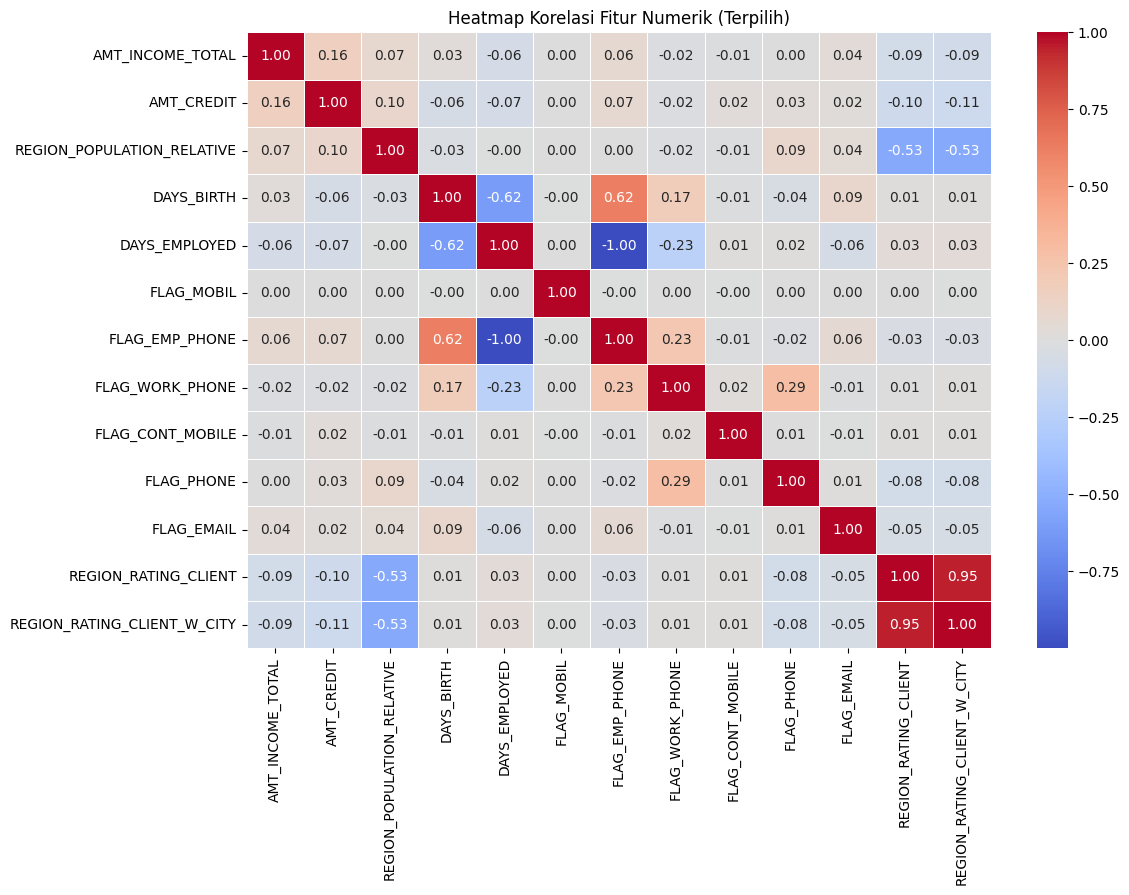

In [130]:
numerical_columns = df_train[['AMT_INCOME_TOTAL', 'AMT_CREDIT', 'REGION_POPULATION_RELATIVE', 
                              'DAYS_BIRTH', 'DAYS_EMPLOYED', 'FLAG_MOBIL', 'FLAG_EMP_PHONE', 
                              'FLAG_WORK_PHONE', 'FLAG_CONT_MOBILE', 'FLAG_PHONE', 'FLAG_EMAIL', 
                              'REGION_RATING_CLIENT', 'REGION_RATING_CLIENT_W_CITY']]

correlation_matrix = numerical_columns.corr()
plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Heatmap Korelasi Fitur Numerik (Terpilih)')
plt.show()

## Distribusi Target

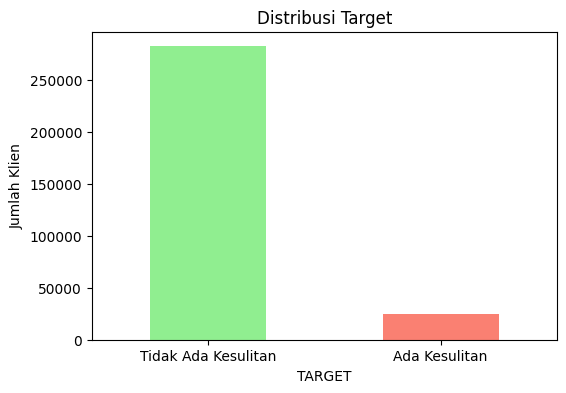

In [131]:
plt.figure(figsize=(6, 4))
df_train['TARGET'].value_counts().plot(kind='bar', color=['lightgreen', 'salmon'])
plt.title('Distribusi Target')
plt.xlabel('TARGET')
plt.ylabel('Jumlah Klien')
plt.xticks([0, 1], ['Tidak Ada Kesulitan', 'Ada Kesulitan'], rotation=0)
plt.show()

## Jumlah Klien Berdasarkan Jenis Kelamin

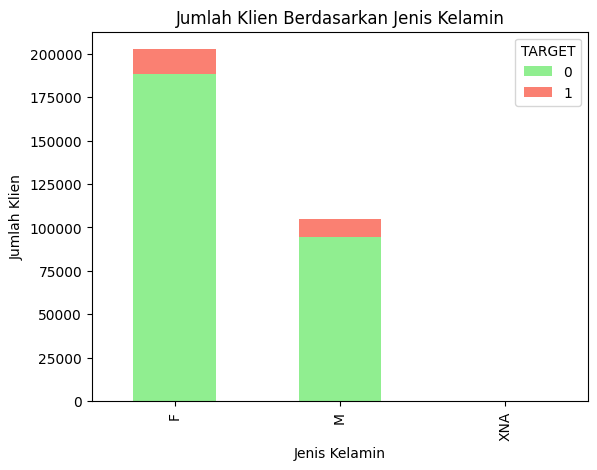

In [132]:
gender_target = df_train.groupby('CODE_GENDER')['TARGET'].value_counts().unstack()
gender_target.plot(kind='bar', stacked=True, color=['lightgreen', 'salmon'])
plt.title('Jumlah Klien Berdasarkan Jenis Kelamin')
plt.xlabel('Jenis Kelamin')
plt.ylabel('Jumlah Klien')
plt.show()

## Jumlah Klien Berdasarkan Jenis Penghasilan

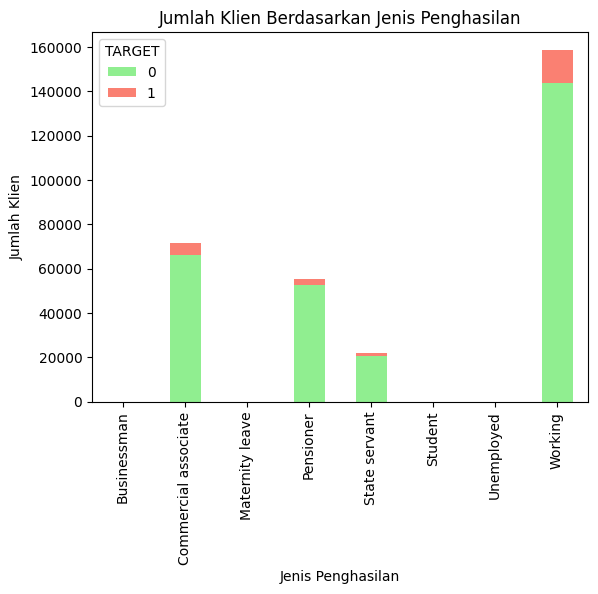

In [133]:
income_target = df_train.groupby('NAME_INCOME_TYPE')['TARGET'].value_counts().unstack()
income_target.plot(kind='bar', stacked= True, color=['lightgreen', 'salmon'])
plt.title('Jumlah Klien Berdasarkan Jenis Penghasilan')
plt.xlabel('Jenis Penghasilan')
plt.ylabel('Jumlah Klien')
plt.show()

## Jumlah Klien Berdasarkan Pendidikan

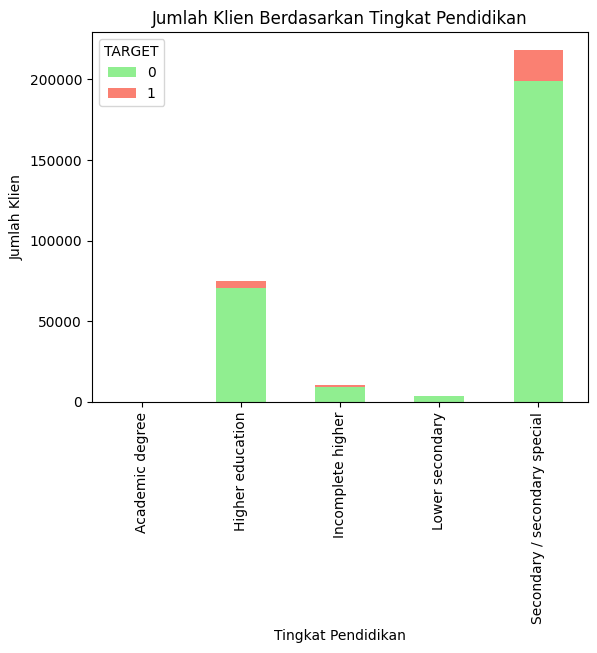

In [134]:
education_target = df_train.groupby('NAME_EDUCATION_TYPE')['TARGET'].value_counts().unstack()
education_target.plot(kind='bar', stacked = True, color=['lightgreen', 'salmon'])
plt.title('Jumlah Klien Berdasarkan Tingkat Pendidikan')
plt.xlabel('Tingkat Pendidikan')
plt.ylabel('Jumlah Klien')
plt.show()

## Jumlah Klien Berdasarkan Status Keluarga

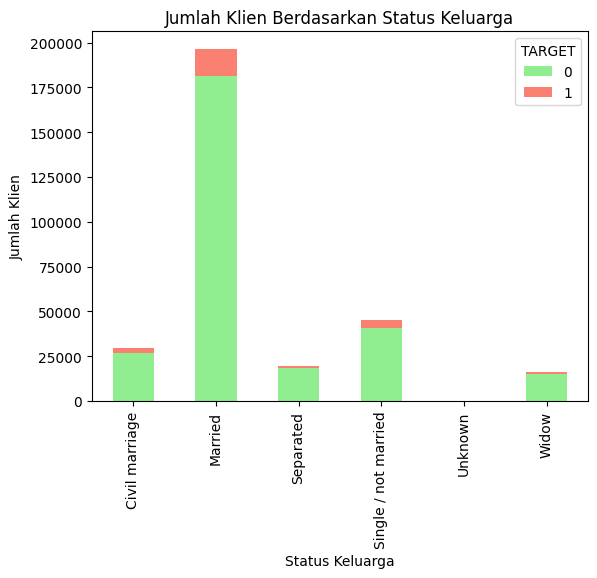

In [135]:
family_status_target = df_train.groupby('NAME_FAMILY_STATUS')['TARGET'].value_counts().unstack()
family_status_target.plot(kind='bar', stacked = True, color=['lightgreen', 'salmon'])
plt.title('Jumlah Klien Berdasarkan Status Keluarga')
plt.xlabel('Status Keluarga')
plt.ylabel('Jumlah Klien')
plt.show()

## Jumlah Klien Berdasarkan Tipe Hunian

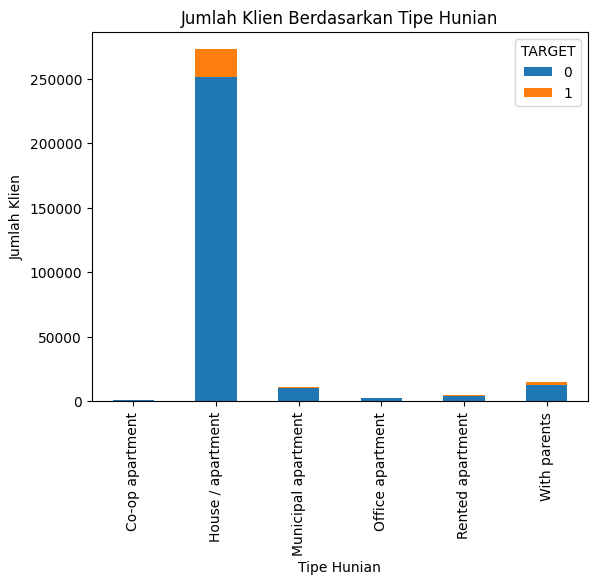

In [136]:
housing_type_target = df_train.groupby('NAME_HOUSING_TYPE')['TARGET'].value_counts().unstack()
housing_type_target.plot(kind='bar', stacked=True)
plt.title('Jumlah Klien Berdasarkan Tipe Hunian')
plt.xlabel('Tipe Hunian')
plt.ylabel('Jumlah Klien')
plt.show()

# Data Prepocessing

## Train Dataset

### Menghapus Variabel Yang Kurang Relevan

In [137]:
df_train.drop(['SK_ID_CURR','FLAG_DOCUMENT_2','FLAG_DOCUMENT_3', 'FLAG_DOCUMENT_4', 'FLAG_DOCUMENT_5',
               'FLAG_DOCUMENT_6','FLAG_DOCUMENT_7', 'FLAG_DOCUMENT_8', 'FLAG_DOCUMENT_9',
               'FLAG_DOCUMENT_10','FLAG_DOCUMENT_11','FLAG_DOCUMENT_12','FLAG_DOCUMENT_13',
               'FLAG_DOCUMENT_14','FLAG_DOCUMENT_15','FLAG_DOCUMENT_16','FLAG_DOCUMENT_17',
               'FLAG_DOCUMENT_18','FLAG_DOCUMENT_19','FLAG_DOCUMENT_20','FLAG_DOCUMENT_21',
               'DAYS_LAST_PHONE_CHANGE', 'AMT_REQ_CREDIT_BUREAU_HOUR', 'AMT_REQ_CREDIT_BUREAU_DAY', 'AMT_REQ_CREDIT_BUREAU_WEEK',
               'AMT_REQ_CREDIT_BUREAU_MON', 'AMT_REQ_CREDIT_BUREAU_QRT', 'AMT_REQ_CREDIT_BUREAU_YEAR',
               'OWN_CAR_AGE', 'DAYS_EMPLOYED','DAYS_REGISTRATION','DAYS_ID_PUBLISH','WEEKDAY_APPR_PROCESS_START',
               'HOUR_APPR_PROCESS_START', 'REG_REGION_NOT_LIVE_REGION','REG_REGION_NOT_WORK_REGION',
               'LIVE_REGION_NOT_WORK_REGION', 'REG_CITY_NOT_LIVE_CITY', 'REG_CITY_NOT_WORK_CITY',
               'LIVE_CITY_NOT_WORK_CITY',], axis=1, inplace=True)

### Menghapus Duplikat Data

In [138]:
df_train.drop_duplicates(inplace=True)

### Menghapus Missing Values

In [139]:
df_train.dropna(axis=1, inplace=True)

### Informasi Dataset

In [140]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 307511 entries, 0 to 307510
Data columns (total 23 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   TARGET                       307511 non-null  int64  
 1   NAME_CONTRACT_TYPE           307511 non-null  object 
 2   CODE_GENDER                  307511 non-null  object 
 3   FLAG_OWN_CAR                 307511 non-null  object 
 4   FLAG_OWN_REALTY              307511 non-null  object 
 5   CNT_CHILDREN                 307511 non-null  int64  
 6   AMT_INCOME_TOTAL             307511 non-null  float64
 7   AMT_CREDIT                   307511 non-null  float64
 8   NAME_INCOME_TYPE             307511 non-null  object 
 9   NAME_EDUCATION_TYPE          307511 non-null  object 
 10  NAME_FAMILY_STATUS           307511 non-null  object 
 11  NAME_HOUSING_TYPE            307511 non-null  object 
 12  REGION_POPULATION_RELATIVE   307511 non-null  float64
 13 

In [141]:
df_train.head()

,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,...,DAYS_BIRTH,FLAG_MOBIL,FLAG_EMP_PHONE,FLAG_WORK_PHONE,FLAG_CONT_MOBILE,FLAG_PHONE,FLAG_EMAIL,REGION_RATING_CLIENT,REGION_RATING_CLIENT_W_CITY,ORGANIZATION_TYPE
0,1,Cash loans,M,N,Y,0,202500.0,406597.5,Working,Secondary / secondary special,...,-9461,1,1,0,1,1,0,2,2,Business Entity Type 3
1,0,Cash loans,F,N,N,0,270000.0,1293502.5,State servant,Higher education,...,-16765,1,1,0,1,1,0,1,1,School
2,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,Working,Secondary / secondary special,...,-19046,1,1,1,1,1,0,2,2,Government
3,0,Cash loans,F,N,Y,0,135000.0,312682.5,Working,Secondary / secondary special,...,-19005,1,1,0,1,0,0,2,2,Business Entity Type 3
4,0,Cash loans,M,N,Y,0,121500.0,513000.0,Working,Secondary / secondary special,...,-19932,1,1,0,1,0,0,2,2,Religion


### Feature Engineering

#### Perubahan Kolom DAYS_BIRTH menjadi Usia

In [142]:
df_train['DAYS_BIRTH'] = df_train['DAYS_BIRTH']//365
df_train['DAYS_BIRTH'] = df_train['DAYS_BIRTH'].abs()
df_train['DAYS_BIRTH']

0         26
1         46
2         53
3         53
4         55
          ..
307506    26
307507    57
307508    42
307509    33
307510    47
Name: DAYS_BIRTH, Length: 307511, dtype: int64

### Label Encoding

In [143]:
label_encoder = LabelEncoder()

df_train['ORGANIZATION_TYPE'] = label_encoder.fit_transform(df_train['ORGANIZATION_TYPE'])
df_train['NAME_HOUSING_TYPE'] = label_encoder.fit_transform(df_train['NAME_HOUSING_TYPE'])
df_train['NAME_FAMILY_STATUS'] = label_encoder.fit_transform(df_train['NAME_FAMILY_STATUS'])
df_train['NAME_EDUCATION_TYPE'] = label_encoder.fit_transform(df_train['NAME_EDUCATION_TYPE'])
df_train['NAME_INCOME_TYPE'] = label_encoder.fit_transform(df_train['NAME_INCOME_TYPE'])
df_train['FLAG_OWN_REALTY'] = label_encoder.fit_transform(df_train['FLAG_OWN_REALTY'])
df_train['FLAG_OWN_CAR'] = label_encoder.fit_transform(df_train['FLAG_OWN_CAR'])
df_train['CODE_GENDER'] = label_encoder.fit_transform(df_train['CODE_GENDER'])
df_train['NAME_CONTRACT_TYPE'] = label_encoder.fit_transform(df_train['NAME_CONTRACT_TYPE'])

### Normalisasi Data

In [144]:
scaler = MinMaxScaler()

normalized_train_data = scaler.fit_transform(df_train)

In [145]:
df_train = pd.DataFrame(normalized_train_data, columns=df_train.columns)
df_train

,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,...,DAYS_BIRTH,FLAG_MOBIL,FLAG_EMP_PHONE,FLAG_WORK_PHONE,FLAG_CONT_MOBILE,FLAG_PHONE,FLAG_EMAIL,REGION_RATING_CLIENT,REGION_RATING_CLIENT_W_CITY,ORGANIZATION_TYPE
0,1.0,0.0,0.5,0.0,1.0,0.0,0.001512,0.090287,1.000000,1.00,...,0.102041,1.0,1.0,0.0,1.0,1.0,0.0,0.5,0.5,0.087719
1,0.0,0.0,0.0,0.0,0.0,0.0,0.002089,0.311736,0.571429,0.25,...,0.510204,1.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,0.684211
2,0.0,1.0,0.5,1.0,1.0,0.0,0.000358,0.022472,1.000000,1.00,...,0.653061,1.0,1.0,1.0,1.0,1.0,0.0,0.5,0.5,0.192982
3,0.0,0.0,0.0,0.0,1.0,0.0,0.000935,0.066837,1.000000,1.00,...,0.653061,1.0,1.0,0.0,1.0,0.0,0.0,0.5,0.5,0.087719
4,0.0,0.0,0.5,0.0,1.0,0.0,0.000819,0.116854,1.000000,1.00,...,0.693878,1.0,1.0,0.0,1.0,0.0,0.0,0.5,0.5,0.649123
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
307506,0.0,0.0,0.5,0.0,0.0,0.0,0.001127,0.052360,1.000000,1.00,...,0.102041,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.754386
307507,0.0,0.0,0.0,0.0,1.0,0.0,0.000396,0.056067,0.428571,1.00,...,0.734694,1.0,0.0,0.0,1.0,1.0,0.0,0.5,0.5,1.000000
307508,0.0,0.0,0.0,0.0,1.0,0.0,0.001089,0.157969,1.000000,0.25,...,0.428571,1.0,1.0,0.0,1.0,0.0,1.0,1.0,1.0,0.684211
307509,1.0,0.0,0.0,0.0,1.0,0.0,0.001243,0.081175,0.142857,1.00,...,0.244898,1.0,1.0,0.0,1.0,0.0,0.0,0.5,0.5,0.052632


## Test Dataset

### Menghapus Variabel Yang Kurang Relevan

In [146]:
df_test.drop(['SK_ID_CURR','FLAG_DOCUMENT_2','FLAG_DOCUMENT_3', 'FLAG_DOCUMENT_4', 'FLAG_DOCUMENT_5',
               'FLAG_DOCUMENT_6','FLAG_DOCUMENT_7', 'FLAG_DOCUMENT_8', 'FLAG_DOCUMENT_9',
               'FLAG_DOCUMENT_10','FLAG_DOCUMENT_11','FLAG_DOCUMENT_12','FLAG_DOCUMENT_13',
               'FLAG_DOCUMENT_14','FLAG_DOCUMENT_15','FLAG_DOCUMENT_16','FLAG_DOCUMENT_17',
               'FLAG_DOCUMENT_18','FLAG_DOCUMENT_19','FLAG_DOCUMENT_20','FLAG_DOCUMENT_21',
               'DAYS_LAST_PHONE_CHANGE', 'AMT_REQ_CREDIT_BUREAU_HOUR', 'AMT_REQ_CREDIT_BUREAU_DAY', 'AMT_REQ_CREDIT_BUREAU_WEEK',
               'AMT_REQ_CREDIT_BUREAU_MON', 'AMT_REQ_CREDIT_BUREAU_QRT', 'AMT_REQ_CREDIT_BUREAU_YEAR',
               'OWN_CAR_AGE', 'DAYS_EMPLOYED','DAYS_REGISTRATION','DAYS_ID_PUBLISH','WEEKDAY_APPR_PROCESS_START',
               'HOUR_APPR_PROCESS_START', 'REG_REGION_NOT_LIVE_REGION','REG_REGION_NOT_WORK_REGION',
               'LIVE_REGION_NOT_WORK_REGION', 'REG_CITY_NOT_LIVE_CITY', 'REG_CITY_NOT_WORK_CITY',
               'LIVE_CITY_NOT_WORK_CITY',], axis=1, inplace=True)

### Menghapus Duplikat Data

In [147]:
df_test.drop_duplicates(inplace=True)

### Menghapus Missing Values

In [148]:
df_test.dropna(axis=1, inplace=True)

### Informasi Dataset

In [149]:
df_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48744 entries, 0 to 48743
Data columns (total 24 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   NAME_CONTRACT_TYPE           48744 non-null  object 
 1   CODE_GENDER                  48744 non-null  object 
 2   FLAG_OWN_CAR                 48744 non-null  object 
 3   FLAG_OWN_REALTY              48744 non-null  object 
 4   CNT_CHILDREN                 48744 non-null  int64  
 5   AMT_INCOME_TOTAL             48744 non-null  float64
 6   AMT_CREDIT                   48744 non-null  float64
 7   AMT_GOODS_PRICE              48744 non-null  float64
 8   NAME_INCOME_TYPE             48744 non-null  object 
 9   NAME_EDUCATION_TYPE          48744 non-null  object 
 10  NAME_FAMILY_STATUS           48744 non-null  object 
 11  NAME_HOUSING_TYPE            48744 non-null  object 
 12  REGION_POPULATION_RELATIVE   48744 non-null  float64
 13  DAYS_BIRTH      

### Feature Engineering

#### Perubahan Kolom DAYS_BIRTH menjadi Usia

In [150]:
df_test['DAYS_BIRTH'] = df_test['DAYS_BIRTH']//365
df_test['DAYS_BIRTH'] = df_test['DAYS_BIRTH'].abs()
df_test['DAYS_BIRTH']

0        53
1        50
2        55
3        39
4        36
         ..
48739    55
48740    31
48741    44
48742    39
48743    39
Name: DAYS_BIRTH, Length: 48744, dtype: int64

### Label Encoding

In [151]:
df_test['ORGANIZATION_TYPE'] = label_encoder.fit_transform(df_test['ORGANIZATION_TYPE'])
df_test['NAME_HOUSING_TYPE'] = label_encoder.fit_transform(df_test['NAME_HOUSING_TYPE'])
df_test['NAME_FAMILY_STATUS'] = label_encoder.fit_transform(df_test['NAME_FAMILY_STATUS'])
df_test['NAME_EDUCATION_TYPE'] = label_encoder.fit_transform(df_test['NAME_EDUCATION_TYPE'])
df_test['NAME_INCOME_TYPE'] = label_encoder.fit_transform(df_test['NAME_INCOME_TYPE'])
df_test['FLAG_OWN_REALTY'] = label_encoder.fit_transform(df_test['FLAG_OWN_REALTY'])
df_test['FLAG_OWN_CAR'] = label_encoder.fit_transform(df_test['FLAG_OWN_CAR'])
df_test['CODE_GENDER'] = label_encoder.fit_transform(df_test['CODE_GENDER'])
df_test['NAME_CONTRACT_TYPE'] = label_encoder.fit_transform(df_test['NAME_CONTRACT_TYPE'])

### Normalisasi Data

In [152]:
scaler = MinMaxScaler()

normalized_test_data = scaler.fit_transform(df_test)

In [153]:
df_test = pd.DataFrame(normalized_test_data, columns=df_test.columns)
df_test

,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_GOODS_PRICE,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,...,FLAG_MOBIL,FLAG_EMP_PHONE,FLAG_WORK_PHONE,FLAG_CONT_MOBILE,FLAG_PHONE,FLAG_EMAIL,CNT_FAM_MEMBERS,REGION_RATING_CLIENT,REGION_RATING_CLIENT_W_CITY,ORGANIZATION_TYPE
0,0.0,0.0,0.0,1.0,0.00,0.024654,0.238037,0.184049,1.000000,0.25,...,1.0,1.0,0.0,1.0,0.0,1.0,0.05,0.5,0.75,0.491228
1,0.0,1.0,0.0,1.0,0.00,0.016440,0.080785,0.061350,1.000000,1.00,...,1.0,1.0,0.0,1.0,0.0,0.0,0.05,0.5,0.75,0.736842
2,0.0,1.0,1.0,1.0,0.00,0.040054,0.280965,0.265849,1.000000,0.25,...,1.0,1.0,0.0,1.0,0.0,0.0,0.05,0.5,0.75,0.947368
3,0.0,0.0,0.0,1.0,0.10,0.065721,0.695297,0.695297,1.000000,1.00,...,1.0,1.0,0.0,1.0,1.0,0.0,0.15,0.5,0.75,0.087719
4,0.0,1.0,1.0,0.0,0.05,0.034920,0.263804,0.263804,1.000000,1.00,...,1.0,1.0,1.0,1.0,0.0,0.0,0.10,0.5,0.75,0.087719
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48739,0.0,0.0,0.0,1.0,0.00,0.021574,0.167035,0.102249,1.000000,1.00,...,1.0,1.0,1.0,1.0,1.0,0.0,0.00,1.0,1.00,0.578947
48740,0.0,0.0,0.0,0.0,0.10,0.029787,0.262401,0.204499,0.166667,1.00,...,1.0,1.0,0.0,1.0,0.0,0.0,0.15,0.5,0.75,0.894737
48741,0.0,0.0,1.0,1.0,0.05,0.040054,0.122699,0.122699,0.166667,1.00,...,1.0,1.0,0.0,1.0,1.0,0.0,0.10,0.5,0.75,0.087719
48742,0.0,1.0,0.0,0.0,0.00,0.045187,0.184049,0.184049,0.166667,0.25,...,1.0,1.0,1.0,1.0,1.0,0.0,0.05,0.5,0.75,0.736842


# Data Modelling

## Train-Test Split

In [154]:
X = df_train.drop('TARGET', axis=1)
y = df_train['TARGET']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## SMOTE & Undersampling

In [155]:
smote = SMOTE(random_state=42)
undersample = RandomUnderSampler(random_state=42)

pipeline = Pipeline(steps=[('smote', smote), ('undersample', undersample)])

X_train_resampled, y_train_resampled = pipeline.fit_resample(X_train, y_train)

## Logistic Regression

In [156]:
lr_model = LogisticRegression(class_weight='balanced', random_state=42)
lr_model.fit(X_train_resampled, y_train_resampled)

y_pred_lr = lr_model.predict(X_test)
y_pred_proba_lr = lr_model.predict_proba(X_test)[:, 1]

### AUC-ROC

In [157]:
auc_lr = roc_auc_score(y_test, y_pred_proba_lr)
print(f"AUC-ROC: {auc_lr}")

AUC-ROC: 0.646113264374671


### MCC

In [158]:
mcc_lr = matthews_corrcoef(y_test, y_pred_lr)
print(f"MCC: {mcc_lr}")

MCC: 0.11691918384717274


### Akurasi Model

In [159]:
print("Akurasi:", accuracy_score(y_test, y_pred_lr))

Akurasi: 0.6011901858445929


### Confusion Matrix

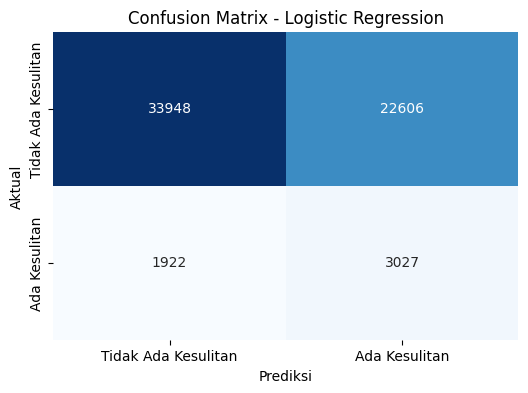

In [160]:
cm = confusion_matrix(y_test, y_pred_lr)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Tidak Ada Kesulitan', 'Ada Kesulitan'], yticklabels=['Tidak Ada Kesulitan', 'Ada Kesulitan'], cbar=False)

plt.title('Confusion Matrix - Logistic Regression')
plt.xlabel('Prediksi')
plt.ylabel('Aktual')
plt.show()

### Classification Report

In [161]:
print("Classification Report:\n", classification_report(y_test, y_pred_lr))

Classification Report:
               precision    recall  f1-score   support

         0.0       0.95      0.60      0.73     56554
         1.0       0.12      0.61      0.20      4949

    accuracy                           0.60     61503
   macro avg       0.53      0.61      0.47     61503
weighted avg       0.88      0.60      0.69     61503



## Random Forest

In [162]:
rf_model = RandomForestClassifier(class_weight='balanced', random_state=42)
rf_model.fit(X_train_resampled, y_train_resampled)

y_pred_rf = rf_model.predict(X_test)
y_pred_proba_rf = rf_model.predict_proba(X_test)[:, 1]

### AUC-ROC

In [163]:
auc_rf = roc_auc_score(y_test, y_pred_proba_rf)
print(f"AUC-ROC: {auc_rf}")

AUC-ROC: 0.6066326543117347


### MCC

In [164]:
mcc_rf = matthews_corrcoef(y_test, y_pred_rf)
print(f"MCC: {mcc_rf}")

MCC: 0.023788756402456136


### Akurasi Model

In [165]:
print("Akurasi:", accuracy_score(y_test, y_pred_rf))

Akurasi: 0.9095491276848284


### Confusion Matrix

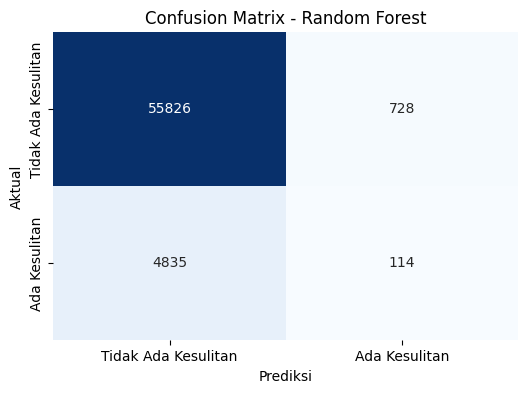

In [166]:
cm = confusion_matrix(y_test, y_pred_rf)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Tidak Ada Kesulitan', 'Ada Kesulitan'], yticklabels=['Tidak Ada Kesulitan', 'Ada Kesulitan'], cbar=False)

plt.title('Confusion Matrix - Random Forest')
plt.xlabel('Prediksi')
plt.ylabel('Aktual')
plt.show()

### Classification Report

In [167]:
print("Classification Report:\n", classification_report(y_test, y_pred_rf))

Classification Report:
               precision    recall  f1-score   support

         0.0       0.92      0.99      0.95     56554
         1.0       0.14      0.02      0.04      4949

    accuracy                           0.91     61503
   macro avg       0.53      0.51      0.50     61503
weighted avg       0.86      0.91      0.88     61503



## Extreme Gradient Boosting

In [168]:
xgb_model = XGBClassifier(scale_pos_weight=1, random_state=42)
xgb_model.fit(X_train_resampled, y_train_resampled)

y_pred_xgb = xgb_model.predict(X_test)
y_pred_proba_xgb = xgb_model.predict_proba(X_test)[:, 1]

### AUC-ROC

In [169]:
auc_xgb = roc_auc_score(y_test, y_pred_proba_xgb)
print(f"AUC-ROC: {auc_xgb}")

AUC-ROC: 0.6131459727856238


### MCC

In [170]:
mcc_xgb = matthews_corrcoef(y_test, y_pred_xgb)
print(f"MCC: {mcc_xgb}")

MCC: 0.02191898777876463


### Akurasi Model

In [171]:
print("Akurasi:", accuracy_score(y_test, y_pred_xgb))

Akurasi: 0.9117441425621514


### Confusion Matrix

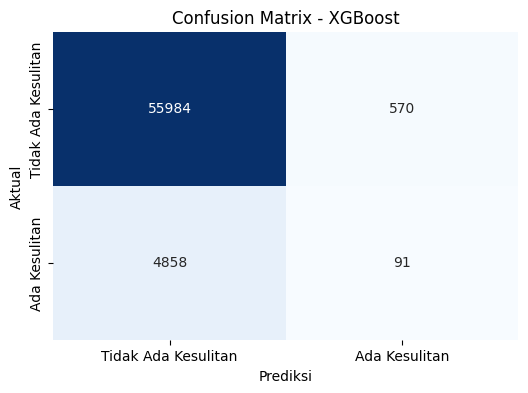

In [172]:
cm = confusion_matrix(y_test, y_pred_xgb)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Tidak Ada Kesulitan', 'Ada Kesulitan'], yticklabels=['Tidak Ada Kesulitan', 'Ada Kesulitan'], cbar=False)

plt.title('Confusion Matrix - XGBoost')
plt.xlabel('Prediksi')
plt.ylabel('Aktual')
plt.show()

### Classification Report

In [173]:
print("Classification Report:\n", classification_report(y_test, y_pred_xgb))

Classification Report:
               precision    recall  f1-score   support

         0.0       0.92      0.99      0.95     56554
         1.0       0.14      0.02      0.03      4949

    accuracy                           0.91     61503
   macro avg       0.53      0.50      0.49     61503
weighted avg       0.86      0.91      0.88     61503

